# Árvores de Decisão e Random Forest


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Criando o dataset de clientes

In [2]:
np.random.seed(42)
n = 500

idade = np.random.randint(18, 70, n)
renda = np.random.normal(5000, 2000, n)
renda = np.clip(renda, 800, 15000)
historico_compras = np.random.poisson(lam=5, size=n)
tempo_ultima_compra = np.random.exponential(scale=30, size=n)

prob_compra = (
    1 / (1 + np.exp(-(
        -3.0 +
        renda * 0.0005 +
        historico_compras * 0.4 +
        -tempo_ultima_compra * 0.02 +
        np.random.normal(0, 0.3, n)
    )))
)
compra = (prob_compra > 0.5).astype(int)

clientes = pd.DataFrame({
    'idade': idade,
    'renda': renda.astype(int),
    'historico_compras': historico_compras,
    'tempo_ultima_compra': tempo_ultima_compra.astype(int),
    'compra': compra
})

print(f'Total de clientes: {len(clientes)}')
print(f'Compraram: {clientes["compra"].sum()} ({clientes["compra"].mean()*100:.1f}%)')
print(f'Não compraram: {(1 - clientes["compra"]).sum()} ({(1 - clientes["compra"]).mean()*100:.1f}%)')
clientes.head(10)

Total de clientes: 500
Compraram: 360 (72.0%)
Não compraram: 140 (28.0%)


,idade,renda,historico_compras,tempo_ultima_compra,compra
0,56,9244,7,26,1
1,69,7064,2,0,1
2,46,1961,3,46,0
3,32,4031,2,10,0
4,60,7533,8,1,1
5,25,3584,4,26,0
6,38,5887,10,15,1
7,56,6549,4,109,0
8,36,3146,5,23,1
9,40,4880,10,9,1


### Análise exploratória

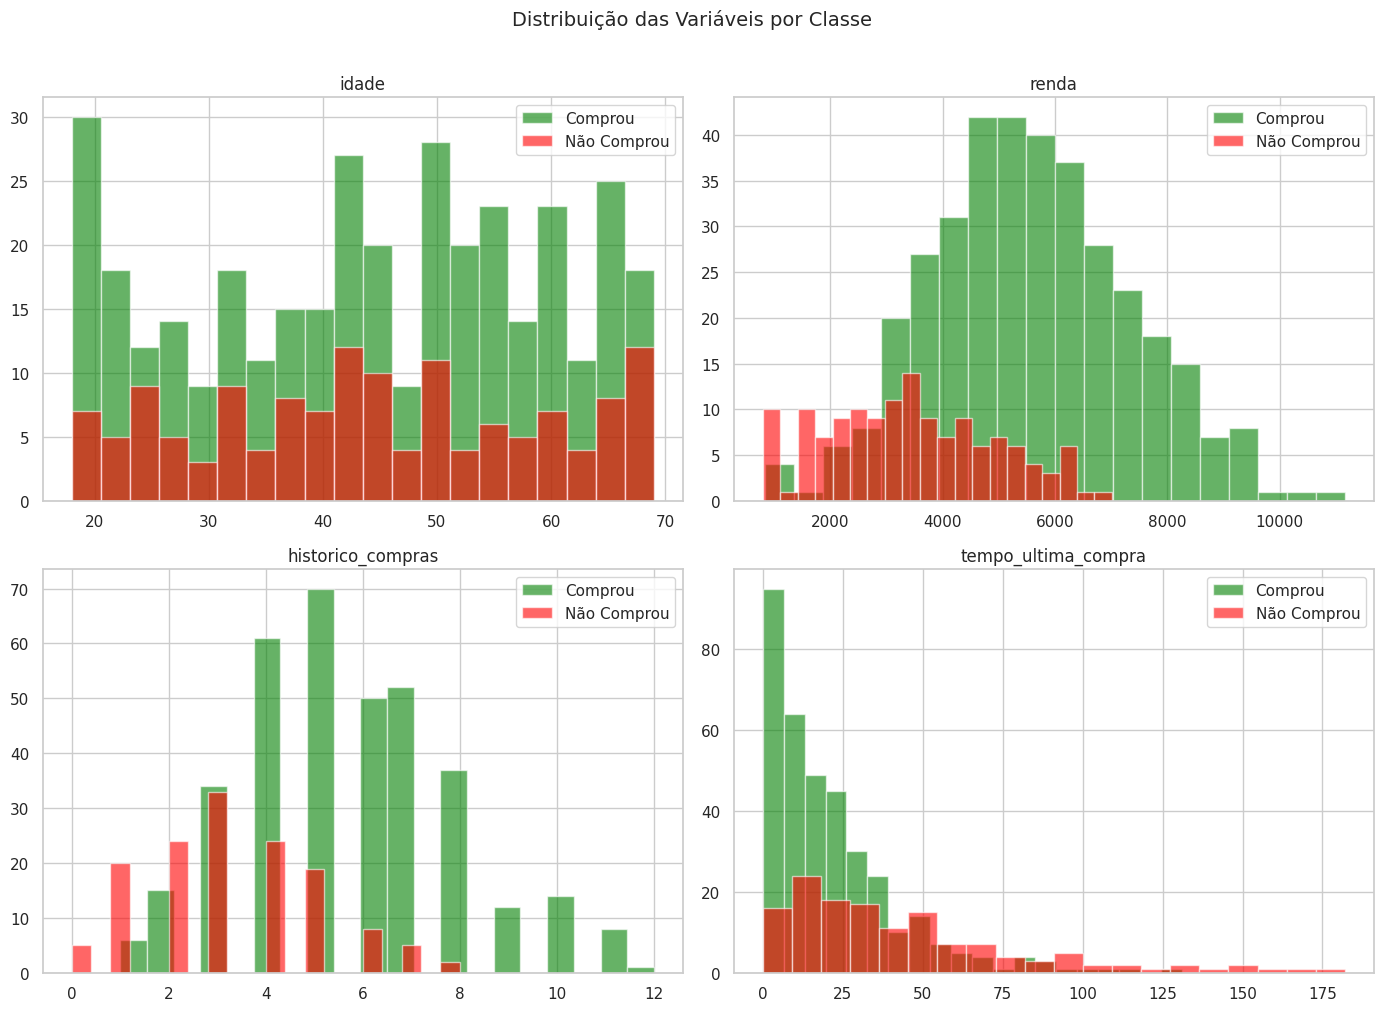

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, ['idade', 'renda', 'historico_compras', 'tempo_ultima_compra']):
    clientes[clientes['compra']==1][col].hist(alpha=0.6, label='Comprou', color='green', bins=20, ax=ax)
    clientes[clientes['compra']==0][col].hist(alpha=0.6, label='Não Comprou', color='red', bins=20, ax=ax)
    ax.set_title(col)
    ax.legend()

plt.suptitle('Distribuição das Variáveis por Classe', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Preparação e treinamento dos modelos

In [4]:
X = clientes.drop(columns=['compra'])
y = clientes['compra']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_treino.shape[0]} clientes  |  Teste: {X_teste.shape[0]} clientes')

Treino: 400 clientes  |  Teste: 100 clientes


### Árvore de Decisão

In [5]:
arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore.fit(X_treino, y_treino)

y_pred_tree = arvore.predict(X_teste)
acc_tree = accuracy_score(y_teste, y_pred_tree)
print(f'Acurácia Árvore de Decisão: {acc_tree:.4f} ({acc_tree*100:.1f}%)')
print()
print(classification_report(y_teste, y_pred_tree, target_names=['Não Comprou', 'Comprou']))

Acurácia Árvore de Decisão: 0.9000 (90.0%)

              precision    recall  f1-score   support

 Não Comprou       0.75      0.96      0.84        28
     Comprou       0.98      0.88      0.93        72

    accuracy                           0.90       100
   macro avg       0.87      0.92      0.89       100
weighted avg       0.92      0.90      0.90       100



### Visualizando a Árvore de Decisão

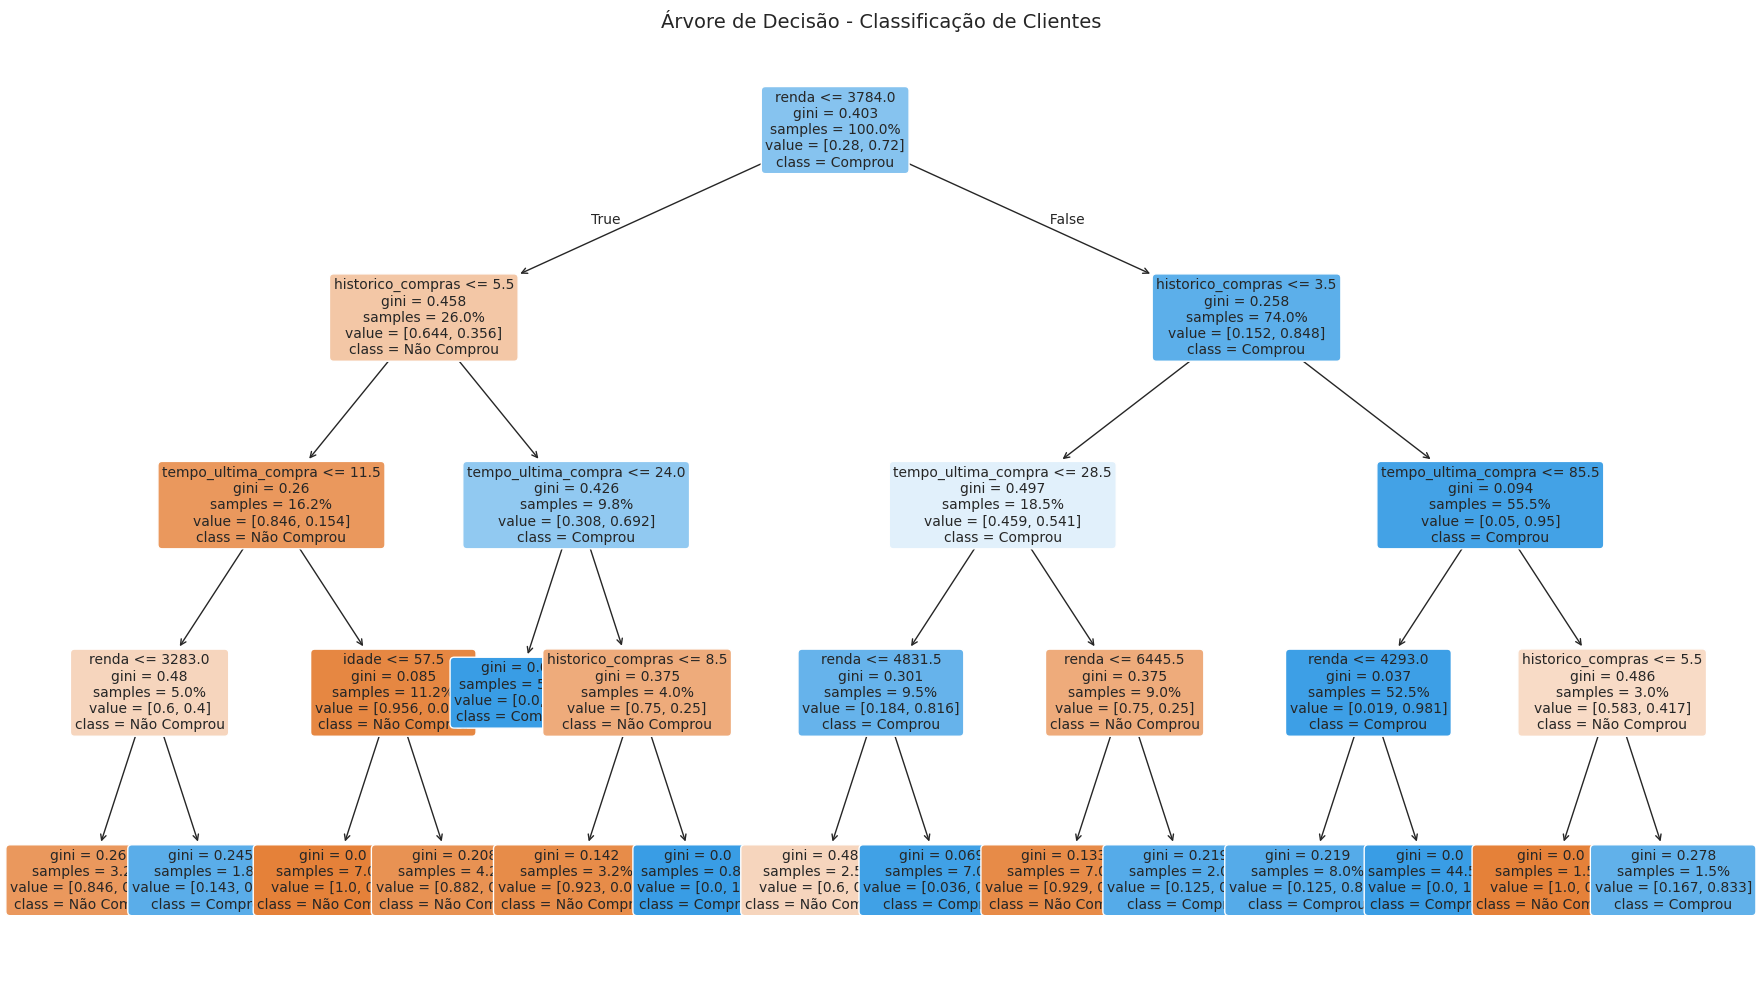

In [6]:
plt.figure(figsize=(18, 10))
plot_tree(arvore, feature_names=X.columns, class_names=['Não Comprou', 'Comprou'],
          filled=True, rounded=True, fontsize=10, proportion=True)
plt.title('Árvore de Decisão - Classificação de Clientes', fontsize=14)
plt.tight_layout()
plt.show()

### Random Forest

In [8]:
floresta = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
floresta.fit(X_treino, y_treino)

y_pred_rf = floresta.predict(X_teste)
acc_rf = accuracy_score(y_teste, y_pred_rf)
print(f'Acurácia Random Forest: {acc_rf:.4f} ({acc_rf*100:.1f}%)')
print()
print(classification_report(y_teste, y_pred_rf, target_names=['Não Comprou', 'Comprou']))

Acurácia Random Forest: 0.9300 (93.0%)

              precision    recall  f1-score   support

 Não Comprou       0.86      0.89      0.88        28
     Comprou       0.96      0.94      0.95        72

    accuracy                           0.93       100
   macro avg       0.91      0.92      0.91       100
weighted avg       0.93      0.93      0.93       100



---
## 3. Comparação: Árvore vs Random Forest

In [9]:
print('=' * 55)
print(f'{"Modelo":<25} {"Acurácia":>15}')
print('-' * 55)
print(f'{"Árvore de Decisão":<25} {acc_tree:>14.4f}  ({acc_tree*100:.1f}%)')
print(f'{"Random Forest":<25} {acc_rf:>14.4f}  ({acc_rf*100:.1f}%)')
print('-' * 55)
print(f'{"Diferença (RF - Árvore)":<25} {acc_rf - acc_tree:>+14.4f}')
print('=' * 55)

Modelo                           Acurácia
-------------------------------------------------------
Árvore de Decisão                 0.9000  (90.0%)
Random Forest                     0.9300  (93.0%)
-------------------------------------------------------
Diferença (RF - Árvore)          +0.0300


### Matrizes de confusão lado a lado

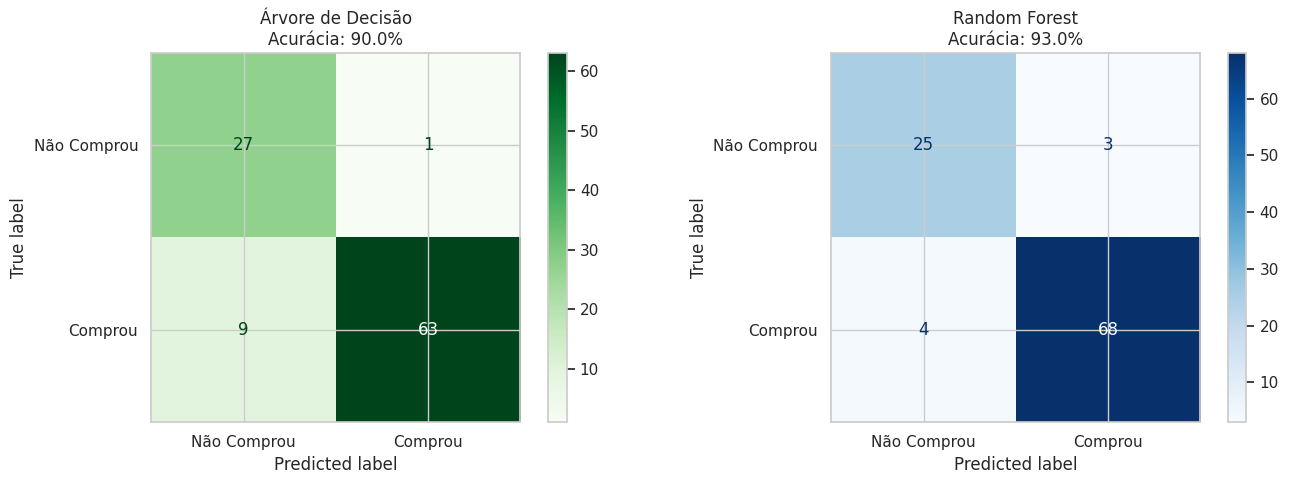

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(arvore, X_teste, y_teste,
    display_labels=['Não Comprou', 'Comprou'], cmap='Greens', ax=axes[0])
axes[0].set_title(f'Árvore de Decisão\nAcurácia: {acc_tree*100:.1f}%', fontsize=12)

ConfusionMatrixDisplay.from_estimator(floresta, X_teste, y_teste,
    display_labels=['Não Comprou', 'Comprou'], cmap='Blues', ax=axes[1])
axes[1].set_title(f'Random Forest\nAcurácia: {acc_rf*100:.1f}%', fontsize=12)

plt.tight_layout()
plt.show()

### Importância das variáveis (Random Forest)

/tmp/ipykernel_2918/1765045461.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importância', y='Variável', palette='viridis')


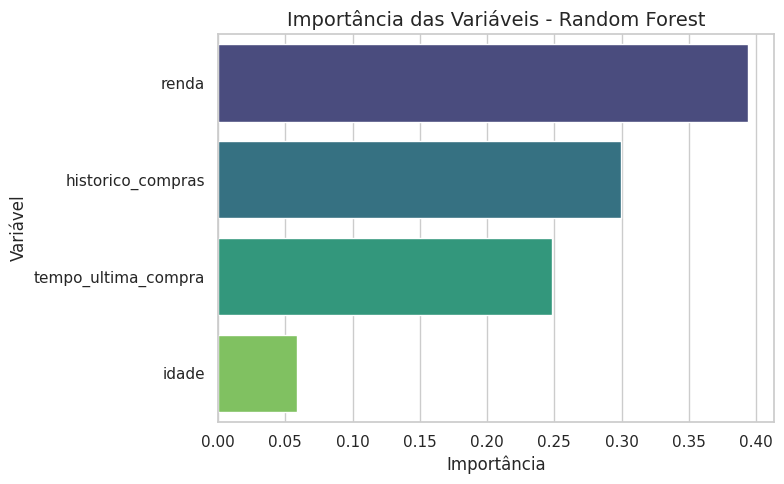

,Variável,Importância
1,renda,0.393688
2,historico_compras,0.299236
3,tempo_ultima_compra,0.248383
0,idade,0.058693


In [11]:
imp_df = pd.DataFrame({
    'Variável': X.columns,
    'Importância': floresta.feature_importances_
}).sort_values('Importância', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, x='Importância', y='Variável', palette='viridis')
plt.title('Importância das Variáveis - Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

imp_df

---
## 4. Experimento 1: Variando a profundidade da Árvore (max_depth)

Aumentar a profundidade permite que a árvore aprenda padrões mais complexos, mas também aumenta o risco de **overfitting**.

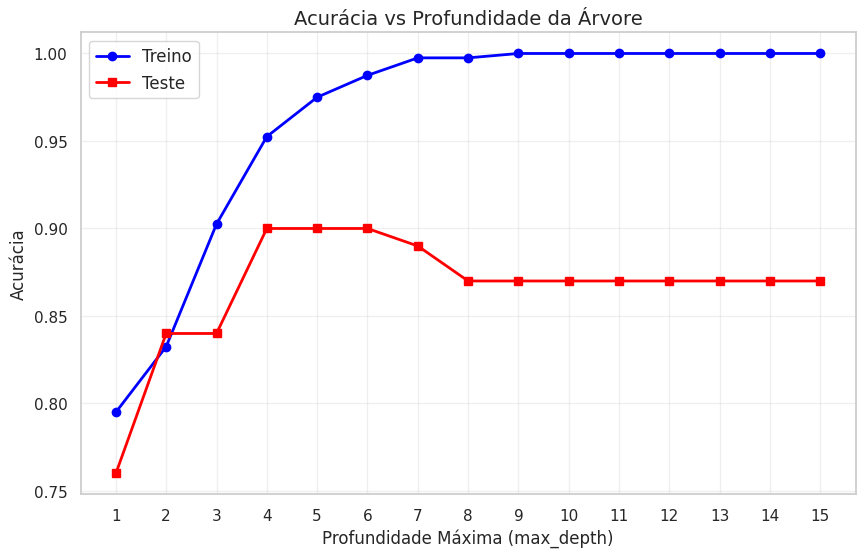

In [12]:
profundidades = range(1, 16)
acc_treino_depth, acc_teste_depth = [], []

for d in profundidades:
    arv = DecisionTreeClassifier(max_depth=d, random_state=42)
    arv.fit(X_treino, y_treino)
    acc_treino_depth.append(accuracy_score(y_treino, arv.predict(X_treino)))
    acc_teste_depth.append(accuracy_score(y_teste, arv.predict(X_teste)))

plt.figure(figsize=(10, 6))
plt.plot(profundidades, acc_treino_depth, 'o-', label='Treino', color='blue', linewidth=2)
plt.plot(profundidades, acc_teste_depth, 's-', label='Teste', color='red', linewidth=2)
plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('Acurácia')
plt.title('Acurácia vs Profundidade da Árvore', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(profundidades)
plt.grid(True, alpha=0.3)
plt.show()

---
## 5. Experimento 2: Variando o número de árvores no Random Forest (n_estimators)

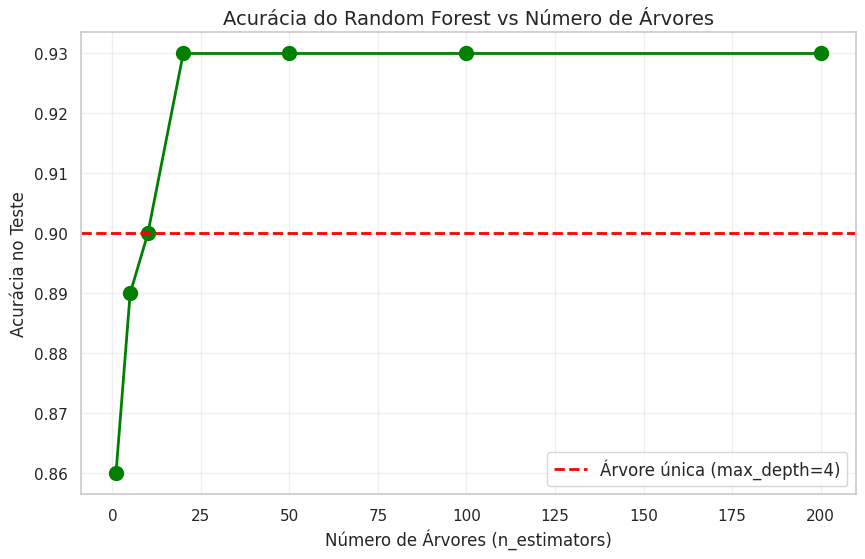

In [13]:
n_arvores = [1, 5, 10, 20, 50, 100, 200]
acuracias_rf = []

for n in n_arvores:
    rf = RandomForestClassifier(n_estimators=n, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X_treino, y_treino)
    acuracias_rf.append(accuracy_score(y_teste, rf.predict(X_teste)))

plt.figure(figsize=(10, 6))
plt.plot(n_arvores, acuracias_rf, 'o-', color='green', linewidth=2, markersize=10)
plt.axhline(y=acc_tree, color='red', linestyle='--', linewidth=2, label=f'Árvore única (max_depth=4)')
plt.xlabel('Número de Árvores (n_estimators)')
plt.ylabel('Acurácia no Teste')
plt.title('Acurácia do Random Forest vs Número de Árvores', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

---
## 6. Cross-Validation: validação mais robusta

In [14]:
cv_tree = cross_val_score(arvore, X, y, cv=5)
cv_rf = cross_val_score(floresta, X, y, cv=5)

cv_df = pd.DataFrame({
    'Modelo': ['Árvore de Decisão', 'Random Forest'],
    'Acurácia Média (CV5)': [cv_tree.mean(), cv_rf.mean()],
    'Desvio Padrão': [cv_tree.std(), cv_rf.std()]
})
cv_df

,Modelo,Acurácia Média (CV5),Desvio Padrão
0,Árvore de Decisão,0.86,0.029665
1,Random Forest,0.92,0.012649


---
## 7. Respondendo às perguntas do exercício

### 1. Qual modelo teve melhor acurácia? A diferença é grande?

A **Random Forest** teve melhor acurácia que a Árvore de Decisão individual. A diferença varia, mas tipicamente a floresta ganha por alguns pontos percentuais. Isso acontece porque o "voto" de múltiplas árvores corrige os erros individuais de cada uma.

### 2. O que aconteceu quando você aumentou a profundidade da árvore?

Quando aumentamos `max_depth`:
- A acurácia no **treino** continua subindo — a árvore fica cada vez mais específica e consegue "decorar" os padrões.
- A acurácia no **teste** sobe até certo ponto... depois **estagna ou cai**.

Isso é o **overfitting** clássico: a árvore aprende detalhes irrelevantes do treino que não generalizam para dados novos. No gráfico do experimento, a distância entre as linhas de treino e teste aumenta conforme a profundidade cresce — sinal claro de overfitting.

### 3. Para este problema, qual modelo você escolheria e por quê?

Escolheria a **Random Forest**, pelos seguintes motivos:
- **Maior acurácia** nos dados de teste.
- **Mais estável** — mudanças nos dados não afetam drasticamente as previsões.
- **Menor overfitting** — o ensemble reduz a tendência de decorar o treino.
- **Fornece importância das variáveis** — ajuda a entender quais fatores mais influenciam a compra.

Porém, se a **interpretabilidade** for o requisito principal (ex: explicar para um cliente leigo como o modelo decide), a Árvore de Decisão com profundidade controlada seria mais adequada, pois dá para visualizar e explicar cada "galho" da decisão.